# 01 — ResPlan Dataset Exploration

Deep dive into the raw ResPlan data: structure, geometry types, room distributions,
coordinate spaces, graph connectivity, and what the floorplans actually look like.

In [14]:
import sys, pickle, random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import networkx as nx
from shapely.geometry import Polygon, MultiPolygon, LineString, MultiLineString, Point, GeometryCollection

# Add ResPlan utils to path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "external" / "ResPlan"))

from resplan_utils import (
    CATEGORY_COLORS, normalize_keys, get_plan_width,
    get_geometries, centroid, geometry_to_mask,
    plot_plan, plan_to_graph, plot_plan_and_graph,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.facecolor"] = "white"

print("Ready.")

Ready.


## 1. Load the dataset

In [15]:
PKL_PATH = PROJECT_ROOT / "data" / "raw" / "ResPlan.pkl"

with open(PKL_PATH, "rb") as f:
    plans = pickle.load(f)

for p in plans:
    normalize_keys(p)

print(f"Total plans: {len(plans)}")

Total plans: 17107


## 2. What's inside a single plan?

Each plan is a `dict`. Let's inspect every key, its Python type, and — if it's a Shapely geometry — the geometry type.

In [16]:
plan = plans[0]

print(f"Keys ({len(plan)}): {sorted(plan.keys())}\n")
for key in sorted(plan.keys()):
    val = plan[key]
    geom_type = type(val).__name__
    extra = ""
    if hasattr(val, "geom_type"):
        extra = f"  geom_type={val.geom_type}"
        if hasattr(val, "is_empty"):
            extra += f"  empty={val.is_empty}"
        if hasattr(val, "bounds") and not val.is_empty:
            extra += f"  bounds={tuple(round(b, 1) for b in val.bounds)}"
    elif isinstance(val, (int, float, str)):
        extra = f"  value={val!r}"
    print(f"  {key:15s}  {geom_type:20s}{extra}")

Keys (24): ['area', 'balcony', 'bathroom', 'bedroom', 'door', 'front_door', 'garden', 'graph', 'id', 'inner', 'kitchen', 'land', 'living', 'neighbor', 'net_area', 'parking', 'pool', 'stair', 'storage', 'unitType', 'veranda', 'wall', 'wall_depth', 'window']

  area             float                 value=116.593265
  balcony          MultiPolygon          geom_type=MultiPolygon  empty=False  bounds=(127.4, 120.7, 255.4, 222.6)
  bathroom         MultiPolygon          geom_type=MultiPolygon  empty=False  bounds=(105.7, 66.7, 256.0, 117.8)
  bedroom          MultiPolygon          geom_type=MultiPolygon  empty=False  bounds=(126.8, 51.2, 234.6, 204.8)
  door             MultiPolygon          geom_type=MultiPolygon  empty=False  bounds=(106.3, 96.4, 226.3, 196.2)
  front_door       Polygon               geom_type=Polygon  empty=False  bounds=(-3.0, 51.8, 0.6, 72.9)
  garden           MultiPolygon          geom_type=MultiPolygon  empty=True
  graph            Graph               
  id       

## 3. Which keys appear across the dataset?

Not every plan has every key. Let's count how often each key appears and what geometry types it takes.

In [17]:
# Count key presence and geometry types across all plans
key_count = Counter()
key_geom_types = defaultdict(Counter)

for p in plans:
    for key, val in p.items():
        if val is None:
            continue
        # Skip empty geometries
        if hasattr(val, "is_empty") and val.is_empty:
            continue
        key_count[key] += 1
        key_geom_types[key][type(val).__name__] += 1

print(f"{'Key':20s} {'Count':>6s}  {'% of plans':>10s}  Geometry types")
print("-" * 80)
for key, count in key_count.most_common():
    pct = 100 * count / len(plans)
    types_str = ", ".join(f"{t}({c})" for t, c in key_geom_types[key].most_common())
    print(f"  {key:18s} {count:6d}  {pct:9.1f}%  {types_str}")

Key                   Count  % of plans  Geometry types
--------------------------------------------------------------------------------
  bathroom            17107      100.0%  MultiPolygon(17107)
  bedroom             17107      100.0%  MultiPolygon(17107)
  inner               17107      100.0%  MultiPolygon(17107)
  wall                17107      100.0%  MultiPolygon(17096), Polygon(11)
  unitType            17107      100.0%  str(17107)
  id                  17107      100.0%  int(17107)
  land                17107      100.0%  MultiPolygon(17107)
  net_area            17107      100.0%  float64(12412), int(4695)
  area                17107      100.0%  float(16785), float64(322)
  neighbor            17107      100.0%  tuple(17107)
  living              17107      100.0%  MultiPolygon(17107)
  wall_depth          17107      100.0%  float(17107)
  graph               17107      100.0%  Graph(17107)
  front_door          17104      100.0%  Polygon(17104)
  door                17103

## 4. Room count distribution

How many rooms (living, kitchen, bedroom, bathroom, balcony) does each plan have?
This matters because HouseDiffusion groups training data by room count.

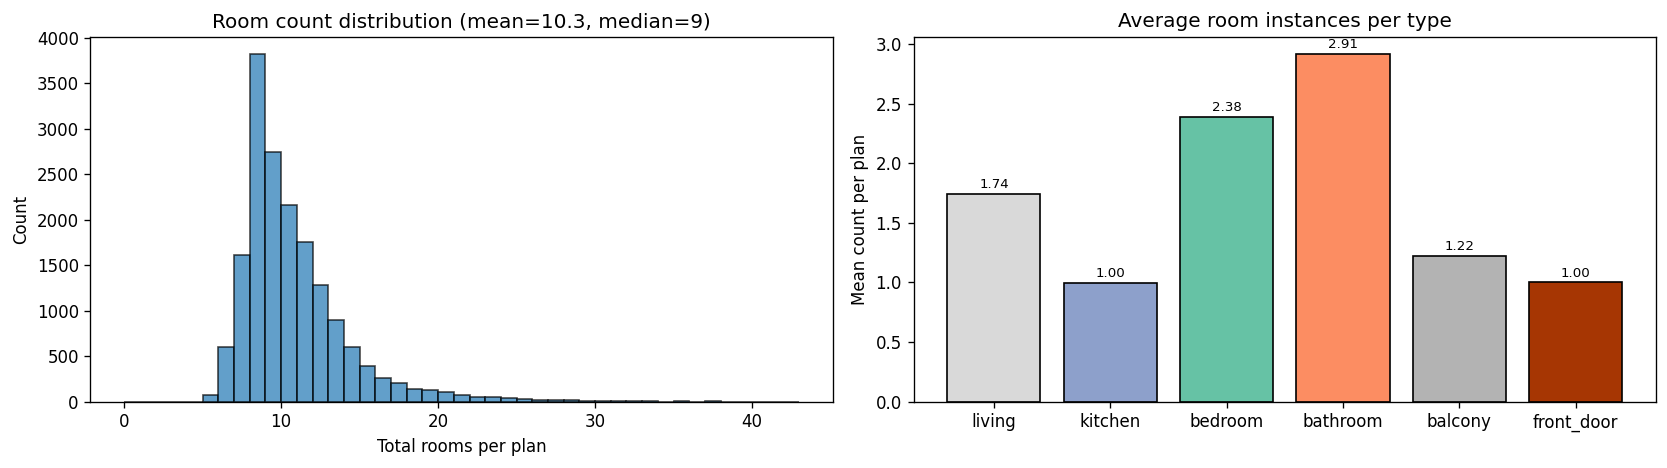

Room count range: 5 – 42


In [18]:
ROOM_KEYS = ["living", "kitchen", "bedroom", "bathroom", "balcony", "front_door"]

def count_rooms(plan):
    """Count individual room polygons (MultiPolygon → multiple rooms)."""
    total = 0
    per_type = {}
    for key in ROOM_KEYS:
        parts = get_geometries(plan.get(key))
        per_type[key] = len(parts)
        total += len(parts)
    return total, per_type

room_counts = []
per_type_counts = defaultdict(list)

for p in plans:
    total, per_type = count_rooms(p)
    room_counts.append(total)
    for k, v in per_type.items():
        per_type_counts[k].append(v)

room_counts = np.array(room_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Total room count histogram
axes[0].hist(room_counts, bins=range(0, room_counts.max() + 2), edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Total rooms per plan")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Room count distribution (mean={room_counts.mean():.1f}, median={np.median(room_counts):.0f})")

# Per-type breakdown
type_means = {k: np.mean(v) for k, v in per_type_counts.items()}
colors = [CATEGORY_COLORS.get(k, "#999") for k in ROOM_KEYS]
axes[1].bar(ROOM_KEYS, [type_means[k] for k in ROOM_KEYS], color=colors, edgecolor="black")
axes[1].set_ylabel("Mean count per plan")
axes[1].set_title("Average room instances per type")
for i, k in enumerate(ROOM_KEYS):
    axes[1].text(i, type_means[k] + 0.05, f"{type_means[k]:.2f}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

print(f"Room count range: {room_counts.min()} – {room_counts.max()}")

## 5. Coordinate space and plan sizes

What coordinate system do the polygons live in? How large are the plans?

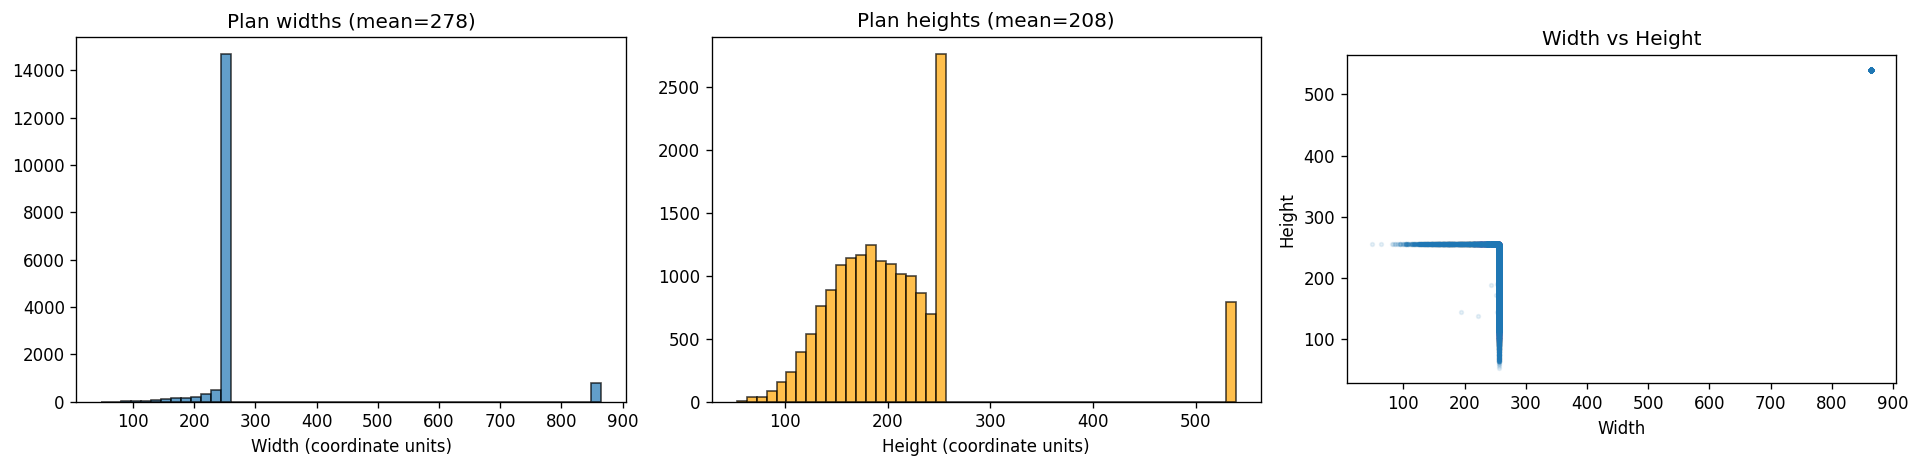

X range across dataset: [-0, 943]
Y range across dataset: [-0, 648]
Typical plan extent: 278 x 208


In [19]:
# Collect bounding boxes from the 'inner' polygon (overall plan outline)
plan_widths = []
plan_heights = []
x_mins, y_mins, x_maxs, y_maxs = [], [], [], []

for p in plans:
    inner = p.get("inner")
    if inner is None or inner.is_empty:
        continue
    x0, y0, x1, y1 = inner.bounds
    plan_widths.append(x1 - x0)
    plan_heights.append(y1 - y0)
    x_mins.append(x0); y_mins.append(y0)
    x_maxs.append(x1); y_maxs.append(y1)

plan_widths = np.array(plan_widths)
plan_heights = np.array(plan_heights)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(plan_widths, bins=50, edgecolor="black", alpha=0.7)
axes[0].set_title(f"Plan widths (mean={plan_widths.mean():.0f})")
axes[0].set_xlabel("Width (coordinate units)")

axes[1].hist(plan_heights, bins=50, edgecolor="black", alpha=0.7, color="orange")
axes[1].set_title(f"Plan heights (mean={plan_heights.mean():.0f})")
axes[1].set_xlabel("Height (coordinate units)")

axes[2].scatter(plan_widths, plan_heights, alpha=0.1, s=5)
axes[2].set_xlabel("Width")
axes[2].set_ylabel("Height")
axes[2].set_title("Width vs Height")
axes[2].set_aspect("equal")

plt.tight_layout()
plt.show()

print(f"X range across dataset: [{min(x_mins):.0f}, {max(x_maxs):.0f}]")
print(f"Y range across dataset: [{min(y_mins):.0f}, {max(y_maxs):.0f}]")
print(f"Typical plan extent: {plan_widths.mean():.0f} x {plan_heights.mean():.0f}")

# Check if there's a wall_width field
ww_values = [float(p.get("wall_width", 0) or 0) for p in plans]
ww_values = [w for w in ww_values if w > 0]
if ww_values:
    print(f"wall_width: min={min(ww_values):.1f}, max={max(ww_values):.1f}, mean={np.mean(ww_values):.1f}")

## 6. Visualize example plans

Random sample of plans rendered with `plot_plan` (colored room polygons).

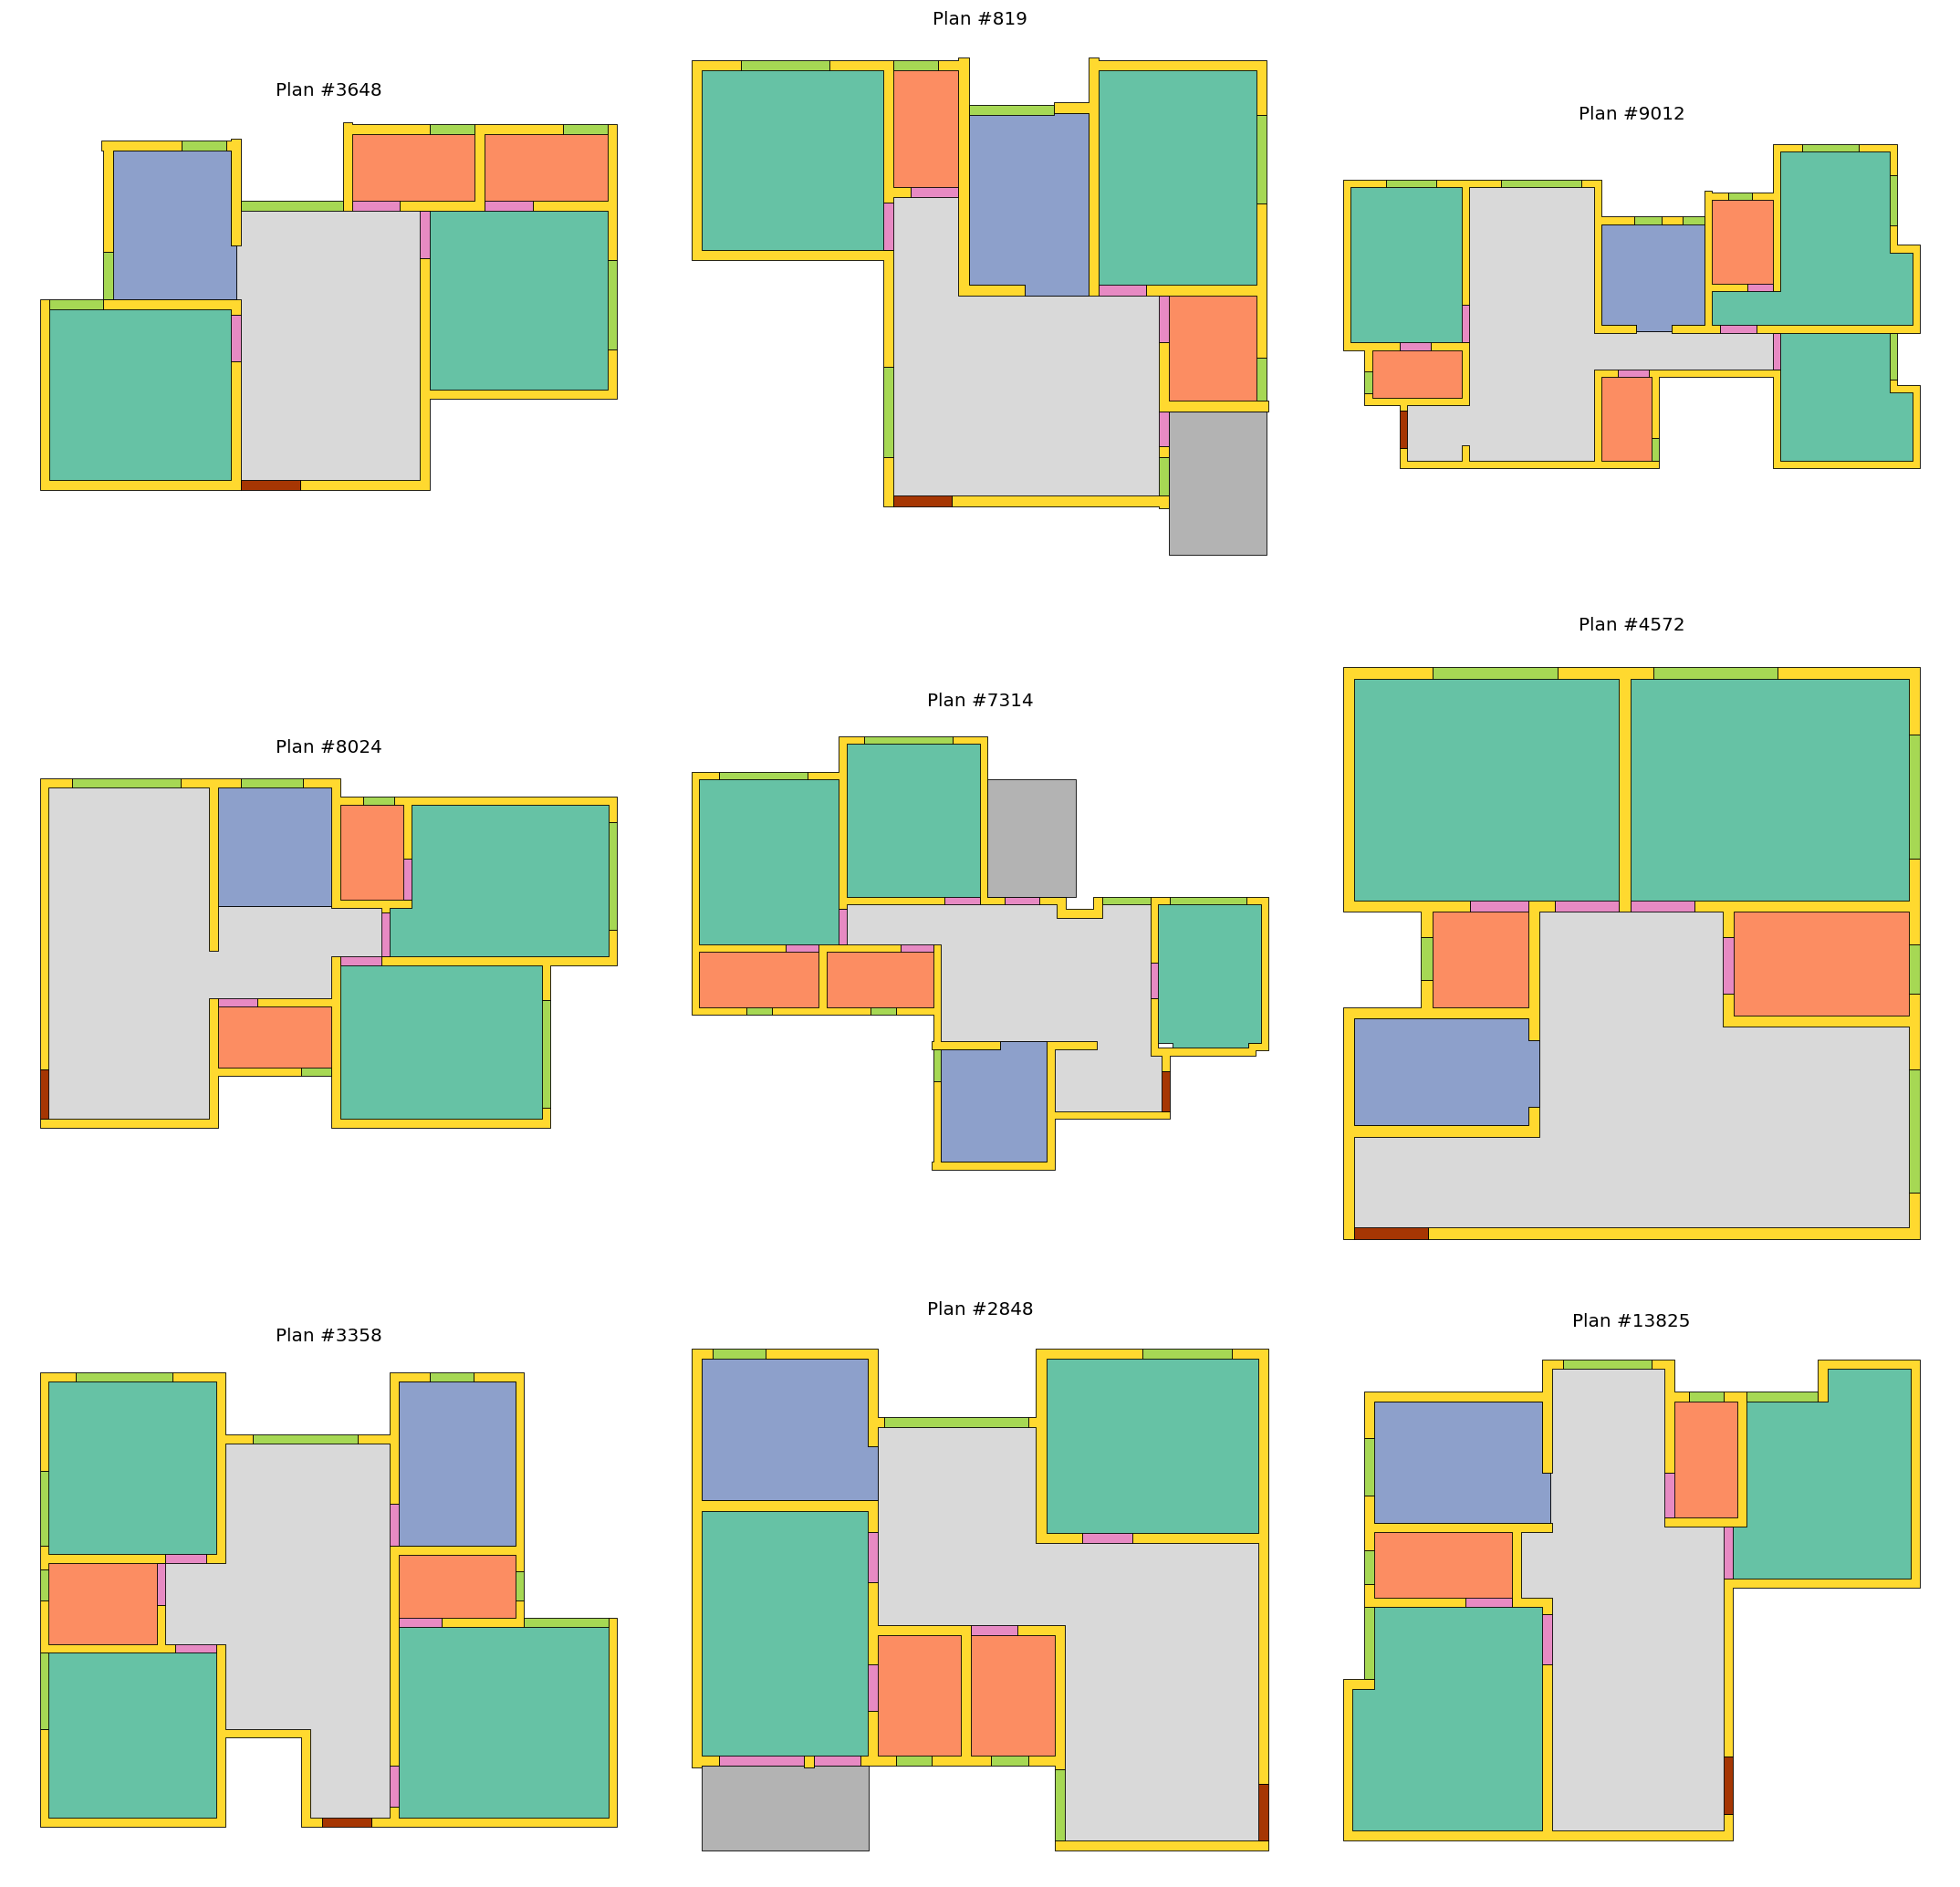

In [20]:
random.seed(42)
indices = random.sample(range(len(plans)), 9)

fig, axes = plt.subplots(3, 3, figsize=(18, 18))
for ax, idx in zip(axes.flat, indices):
    try:
        plot_plan(plans[idx], ax=ax, title=f"Plan #{idx}", legend=False, tight=False)
    except Exception as e:
        ax.set_title(f"Plan #{idx} — ERROR: {e}")
        ax.axis("off")

plt.tight_layout()
plt.show()

## 7. Deep dive: anatomy of a single plan

Break one plan apart and show each geometry layer separately — rooms, walls, doors, windows.

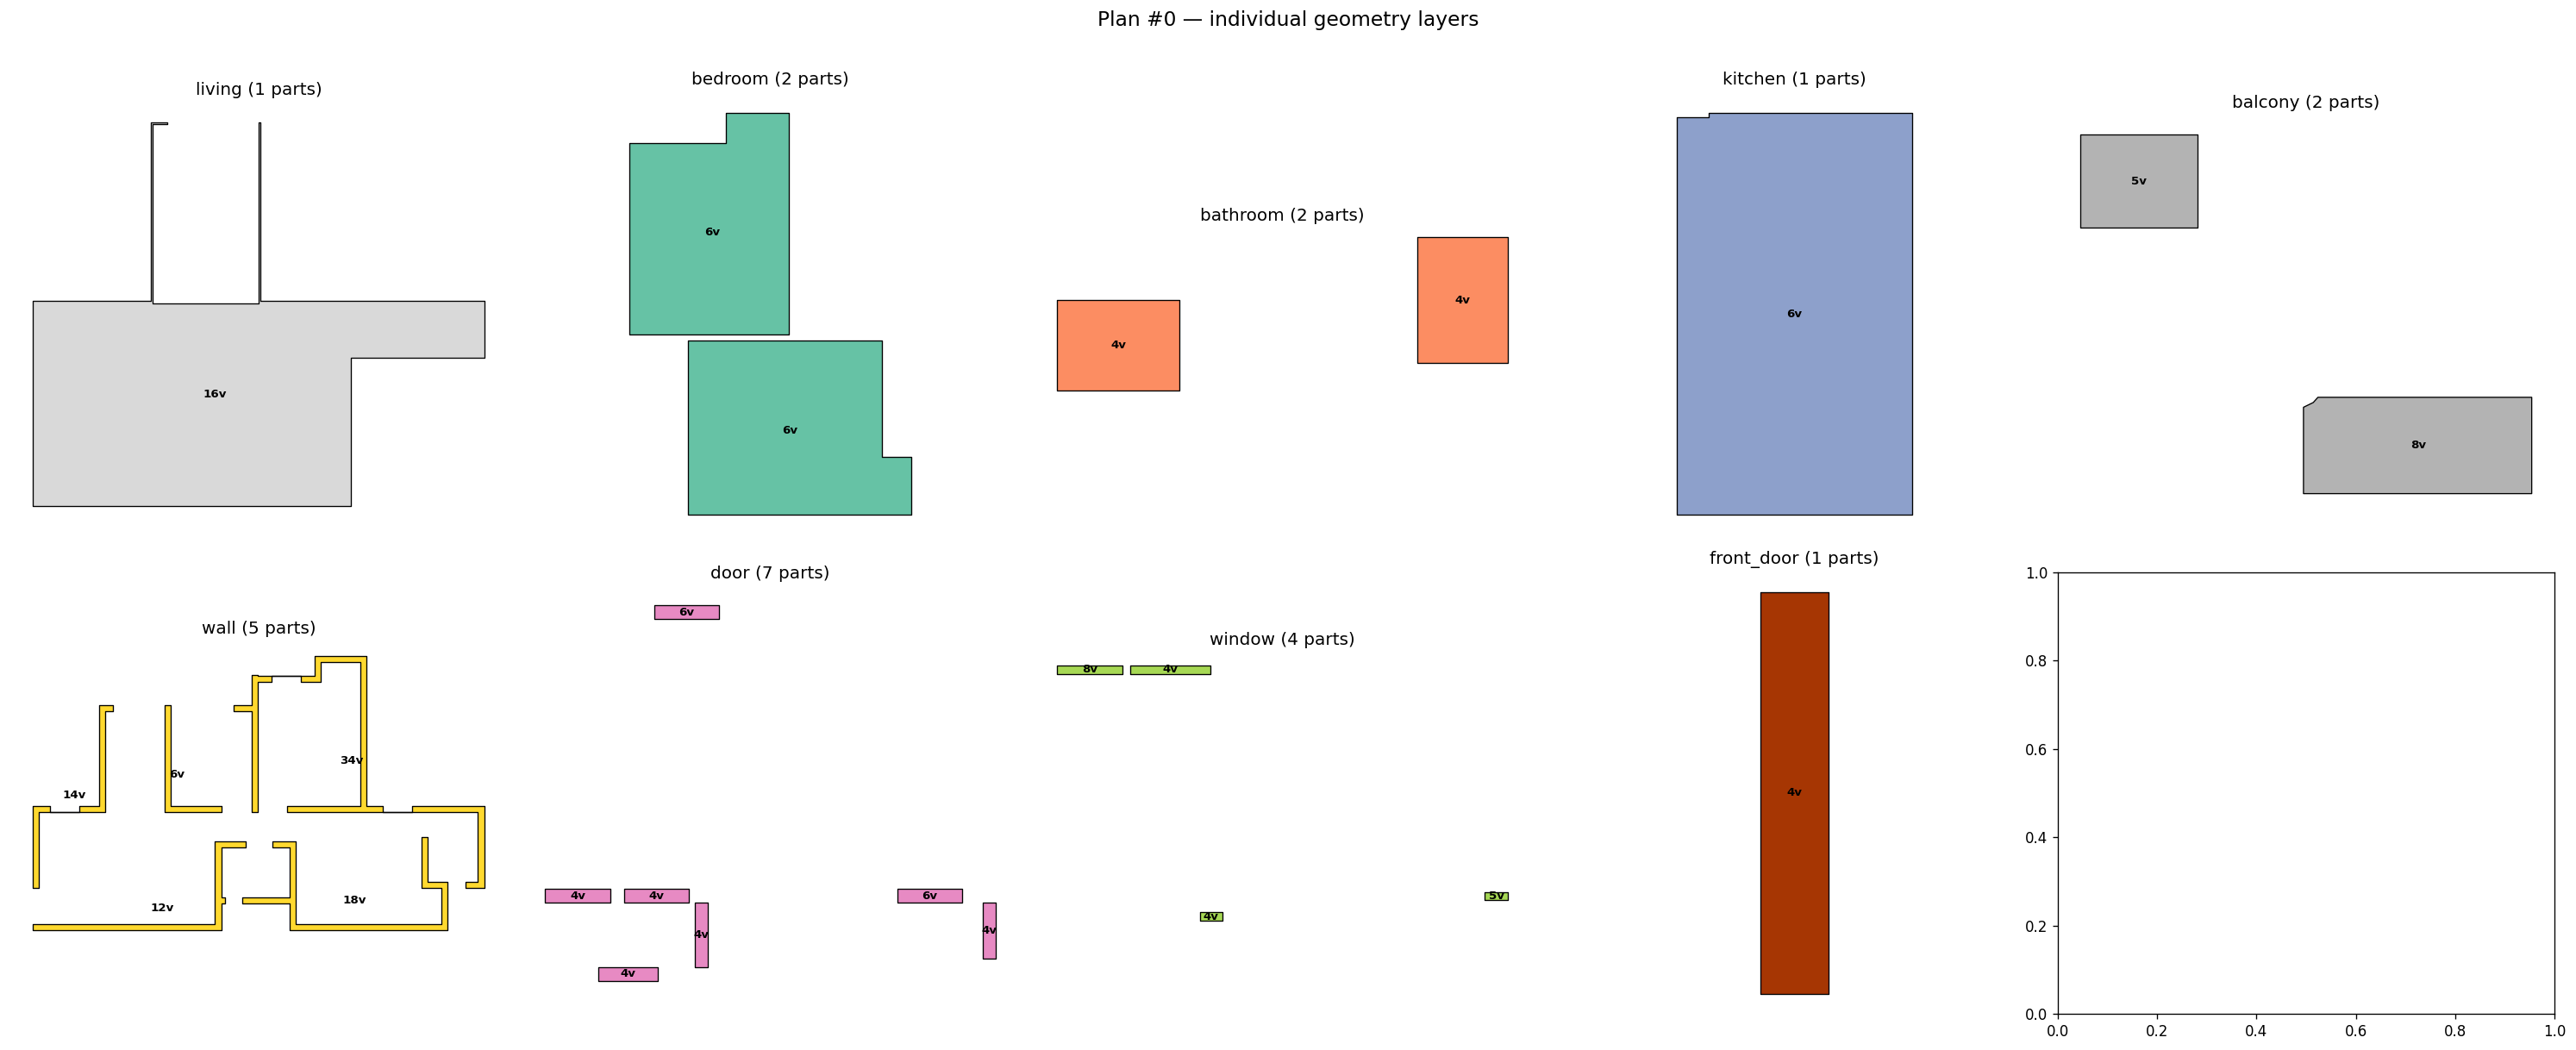

In [21]:
# Pick a plan with a good variety of rooms
plan = plans[0]

LAYER_KEYS = ["living", "bedroom", "bathroom", "kitchen", "balcony", "wall", "door", "window", "front_door"]
present_keys = [k for k in LAYER_KEYS if plan.get(k) is not None and not (hasattr(plan[k], "is_empty") and plan[k].is_empty)]

ncols = min(5, len(present_keys))
nrows = (len(present_keys) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes_flat = axes.flat if hasattr(axes, "flat") else [axes]

import geopandas as gpd

for ax, key in zip(axes_flat, present_keys):
    parts = get_geometries(plan[key])
    if parts:
        gs = gpd.GeoSeries(parts)
        gs.plot(ax=ax, color=CATEGORY_COLORS.get(key, "#999"), edgecolor="black", linewidth=0.8)

        # Show vertex count per polygon
        for i, geom in enumerate(parts):
            if isinstance(geom, Polygon):
                coords = np.array(geom.exterior.coords)[:-1]
                n_verts = len(coords)
                cx, cy = geom.centroid.x, geom.centroid.y
                ax.text(cx, cy, f"{n_verts}v", ha="center", va="center", fontsize=8, fontweight="bold")

    ax.set_title(f"{key} ({len(parts)} parts)")
    ax.set_aspect("equal")
    ax.axis("off")

# Hide unused axes
for ax in list(axes_flat)[len(present_keys):]:
    ax.axis("off")

fig.suptitle(f"Plan #{0} — individual geometry layers", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 8. Polygon complexity: vertex counts per room

How many vertices do room polygons have? This is critical for conversion — HouseDiffusion
represents each room as a sequence of corner points, and the total across all rooms is capped at 100.

C:\Users\nick\AppData\Local\Temp\ipykernel_8064\2961789608.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[2].boxplot(data_for_box, labels=labels_for_box, showfliers=False)


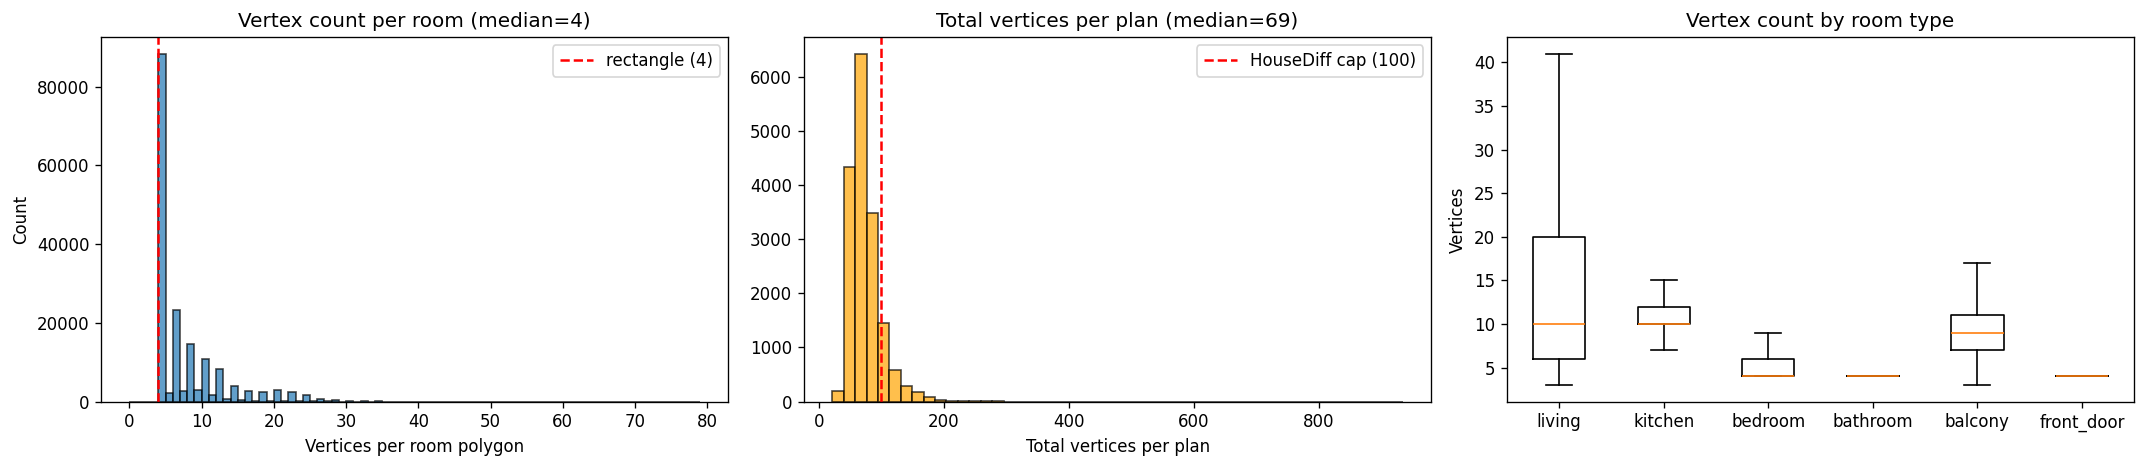

Plans with >100 total vertices (raw): 12.2%
Plans with <=100 total vertices: 87.8%
Per-room vertex count: min=3, median=4, max=241


In [22]:
# Count vertices per room polygon across the dataset
vert_counts_per_room = []  # per individual room polygon
total_verts_per_plan = []  # sum across all rooms in a plan
vert_counts_by_type = defaultdict(list)

for p in plans:
    plan_total = 0
    for key in ROOM_KEYS:
        for geom in get_geometries(p.get(key)):
            if isinstance(geom, Polygon) and not geom.is_empty:
                n = len(np.array(geom.exterior.coords)) - 1  # drop closing vertex
                vert_counts_per_room.append(n)
                vert_counts_by_type[key].append(n)
                plan_total += n
            elif isinstance(geom, LineString):
                n = len(geom.coords)
                vert_counts_per_room.append(n)
                vert_counts_by_type[key].append(n)
                plan_total += n
    total_verts_per_plan.append(plan_total)

vert_counts_per_room = np.array(vert_counts_per_room)
total_verts_per_plan = np.array(total_verts_per_plan)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Per-room vertex count
axes[0].hist(vert_counts_per_room, bins=range(0, min(80, vert_counts_per_room.max() + 2)),
             edgecolor="black", alpha=0.7)
axes[0].axvline(4, color="red", linestyle="--", label="rectangle (4)")
axes[0].set_xlabel("Vertices per room polygon")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Vertex count per room (median={np.median(vert_counts_per_room):.0f})")
axes[0].legend()

# Total vertices per plan
axes[1].hist(total_verts_per_plan, bins=50, edgecolor="black", alpha=0.7, color="orange")
axes[1].axvline(100, color="red", linestyle="--", label="HouseDiff cap (100)")
axes[1].set_xlabel("Total vertices per plan")
axes[1].set_title(f"Total vertices per plan (median={np.median(total_verts_per_plan):.0f})")
axes[1].legend()

# Per type breakdown (box plot)
data_for_box = [vert_counts_by_type[k] for k in ROOM_KEYS if vert_counts_by_type[k]]
labels_for_box = [k for k in ROOM_KEYS if vert_counts_by_type[k]]
bp = axes[2].boxplot(data_for_box, labels=labels_for_box, showfliers=False)
axes[2].set_ylabel("Vertices")
axes[2].set_title("Vertex count by room type")

plt.tight_layout()
plt.show()

pct_over_100 = 100 * np.mean(total_verts_per_plan > 100)
print(f"Plans with >100 total vertices (raw): {pct_over_100:.1f}%")
print(f"Plans with <=100 total vertices: {100 - pct_over_100:.1f}%")
print(f"Per-room vertex count: min={vert_counts_per_room.min()}, "
      f"median={np.median(vert_counts_per_room):.0f}, "
      f"max={vert_counts_per_room.max()}")

## 9. Room adjacency graph

Visualize the NetworkX graph that `plan_to_graph` builds — nodes are rooms, edges
represent adjacency or connections via doors/windows.

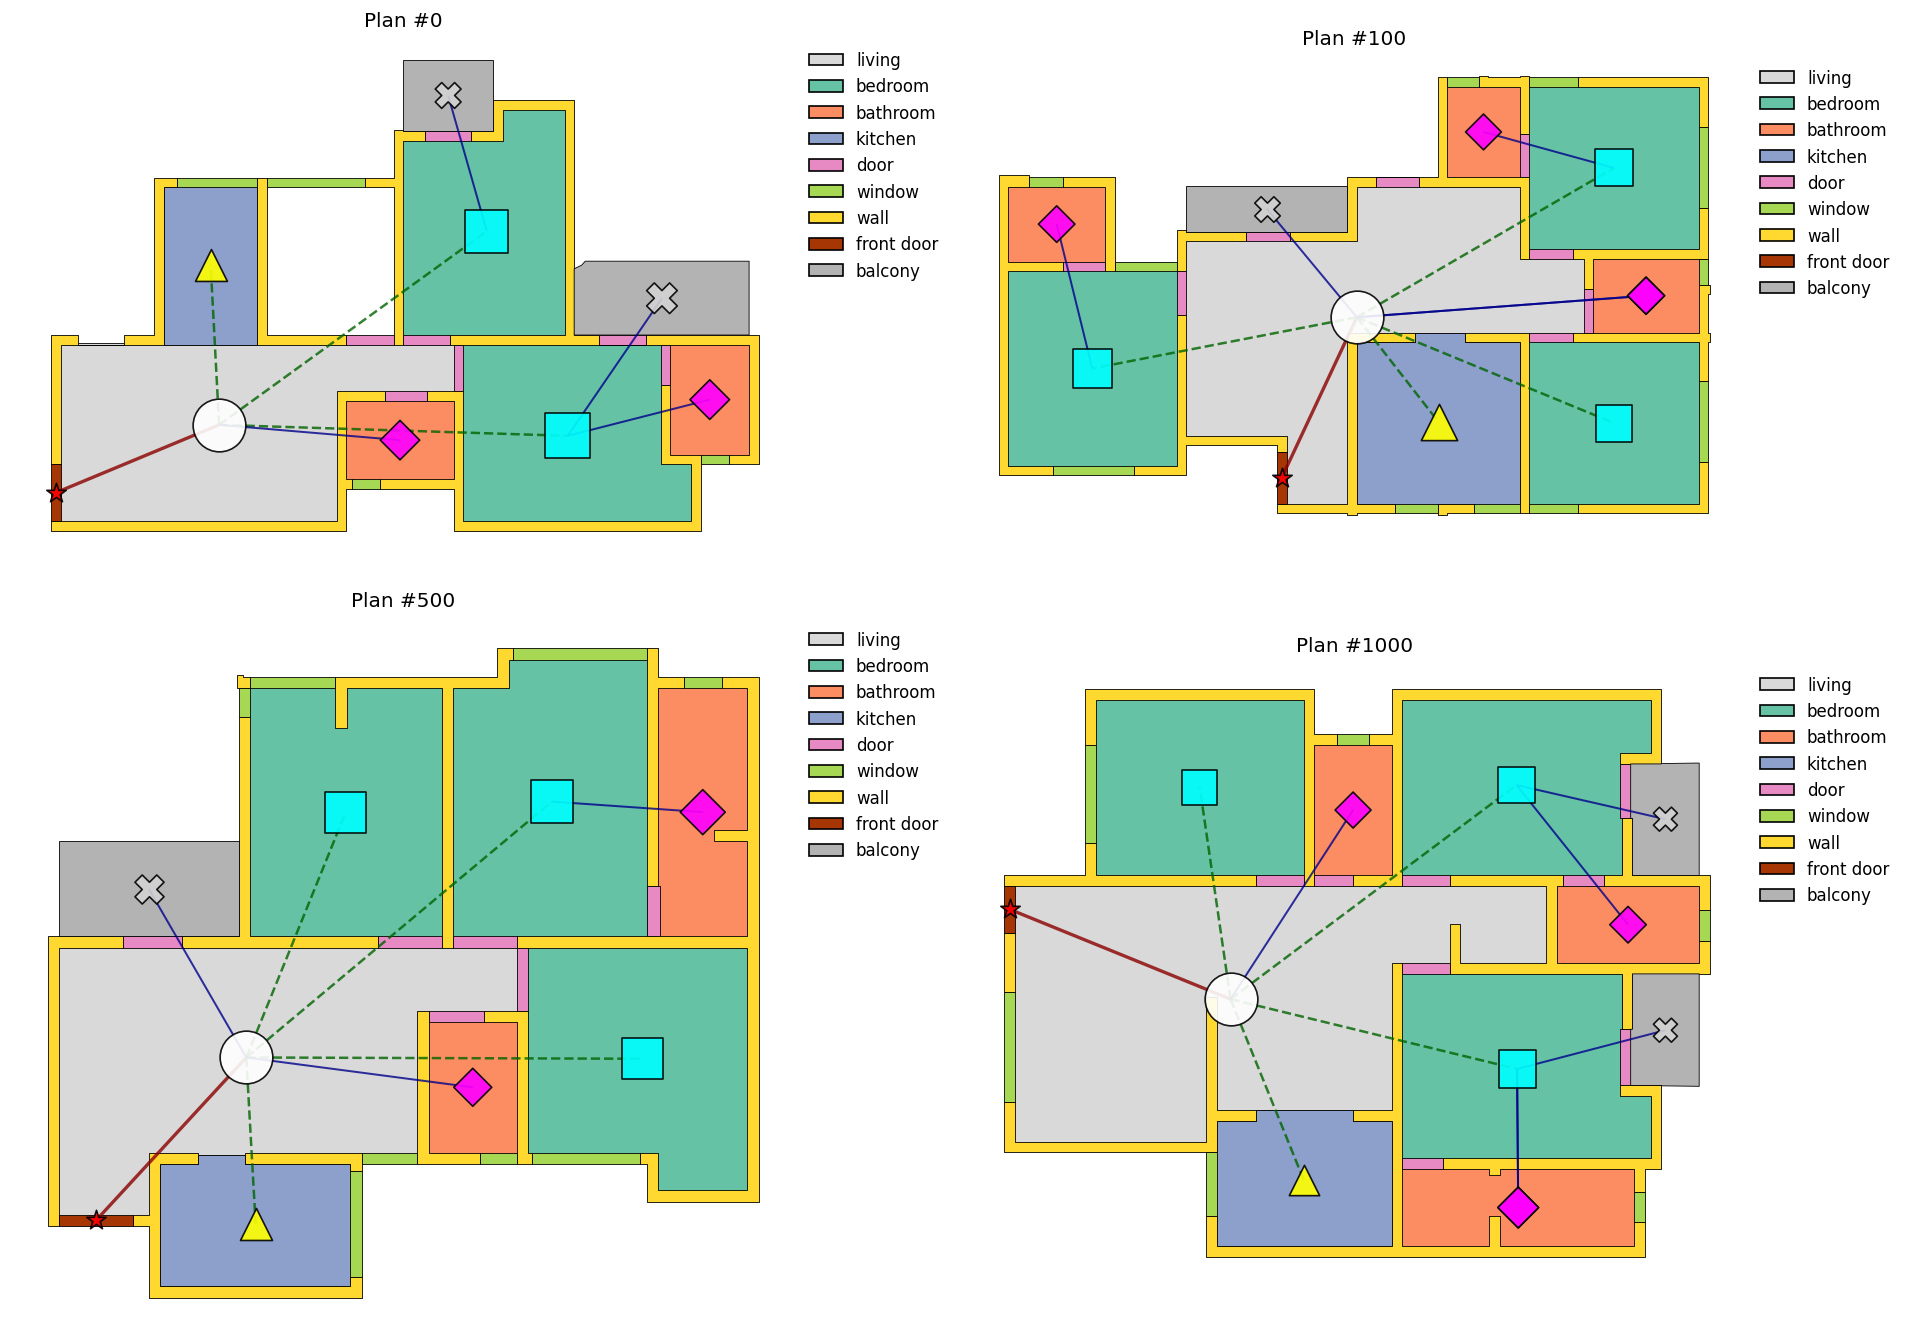

Graph stats (sample of 2000 plans):
  Nodes: mean=10.3, median=9, range=[5, 31]
  Edges: mean=6.6, median=6, range=[2, 22]
  Edge types: {'direct': 1999, 'adjacency': 2989, 'via_door': 7951, 'via_window': 348}


In [23]:
# Show graph overlay for 4 different plans
fig, axes = plt.subplots(2, 2, figsize=(16, 16))
sample_indices = [0, 100, 500, 1000]

for ax, idx in zip(axes.flat, sample_indices):
    try:
        plot_plan_and_graph(plans[idx], ax=ax, title=f"Plan #{idx}")
    except Exception as e:
        ax.set_title(f"Plan #{idx} — ERROR: {e}")
        ax.axis("off")

plt.tight_layout()
plt.show()

# Graph statistics across dataset (sample for speed)
sample_size = min(2000, len(plans))
sample_plans = random.sample(plans, sample_size)

node_counts = []
edge_counts = []
edge_type_counts = defaultdict(int)

for p in sample_plans:
    try:
        G = plan_to_graph(p)
        node_counts.append(G.number_of_nodes())
        edge_counts.append(G.number_of_edges())
        for _, _, data in G.edges(data=True):
            edge_type_counts[data.get("type", "unknown")] += 1
    except Exception:
        continue

print(f"Graph stats (sample of {sample_size} plans):")
print(f"  Nodes: mean={np.mean(node_counts):.1f}, median={np.median(node_counts):.0f}, "
      f"range=[{min(node_counts)}, {max(node_counts)}]")
print(f"  Edges: mean={np.mean(edge_counts):.1f}, median={np.median(edge_counts):.0f}, "
      f"range=[{min(edge_counts)}, {max(edge_counts)}]")
print(f"  Edge types: {dict(edge_type_counts)}")

## 10. Rasterized masks

`geometry_to_mask` converts Shapely geometries to binary pixel masks. This is how the
plan looks when rasterized to a 256x256 canvas — useful for understanding the pixel-space representation.

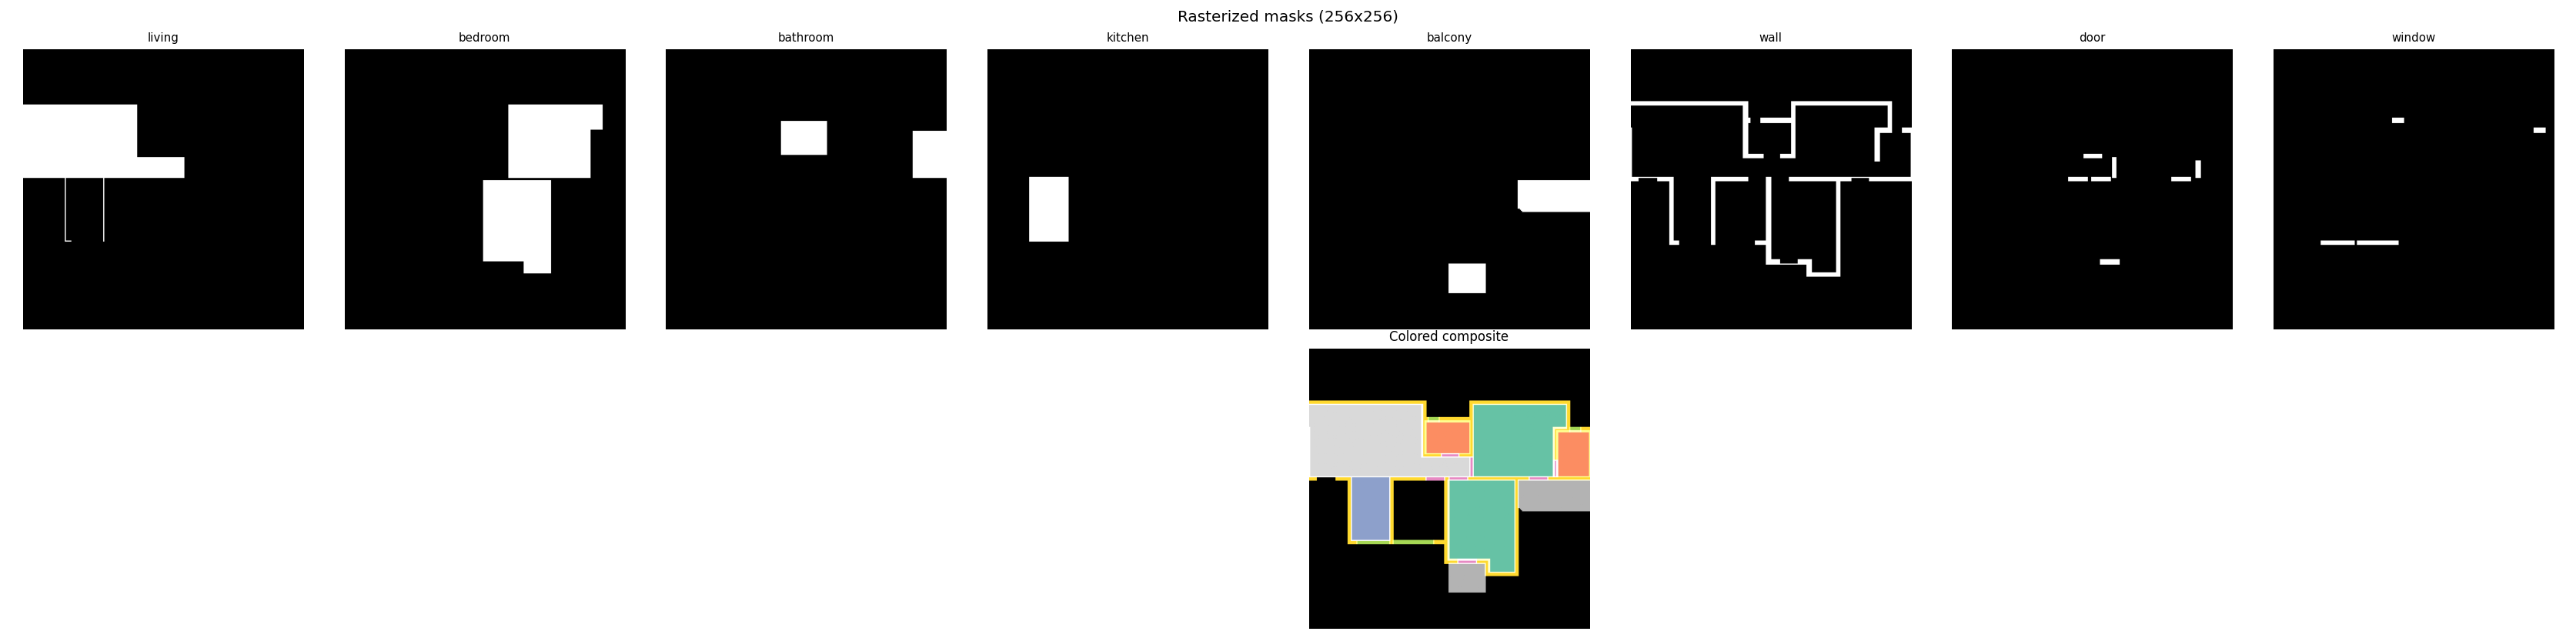

In [24]:
plan = plans[0]
mask_keys = ["living", "bedroom", "bathroom", "kitchen", "balcony", "wall", "door", "window"]
present_mask_keys = [k for k in mask_keys if plan.get(k) is not None]

shape = (256, 256)
fig, axes = plt.subplots(2, len(present_mask_keys), figsize=(3.5 * len(present_mask_keys), 7))

# Row 1: individual binary masks
for i, key in enumerate(present_mask_keys):
    mask = geometry_to_mask(plan.get(key), shape=shape)
    axes[0, i].imshow(mask, cmap="gray")
    axes[0, i].set_title(key, fontsize=9)
    axes[0, i].axis("off")

# Row 2: colored composite
from matplotlib.colors import to_rgb
composite = np.zeros((*shape, 3), dtype=np.float32)
for key in present_mask_keys:
    mask = geometry_to_mask(plan.get(key), shape=shape).astype(np.float32) / 255.0
    color = np.array(to_rgb(CATEGORY_COLORS.get(key, "#999")))
    composite += mask[:, :, None] * color[None, None, :]
composite = np.clip(composite, 0, 1)

# Show composite spanning all columns in row 2
for ax in axes[1]:
    ax.axis("off")
axes[1, len(present_mask_keys) // 2].imshow(composite)
axes[1, len(present_mask_keys) // 2].set_title("Colored composite", fontsize=10)

fig.suptitle("Rasterized masks (256x256)", fontsize=12)
plt.tight_layout()
plt.show()

## 11. Room area distributions

How large are individual rooms of each type? Shows the area of each room polygon in
the original coordinate space.

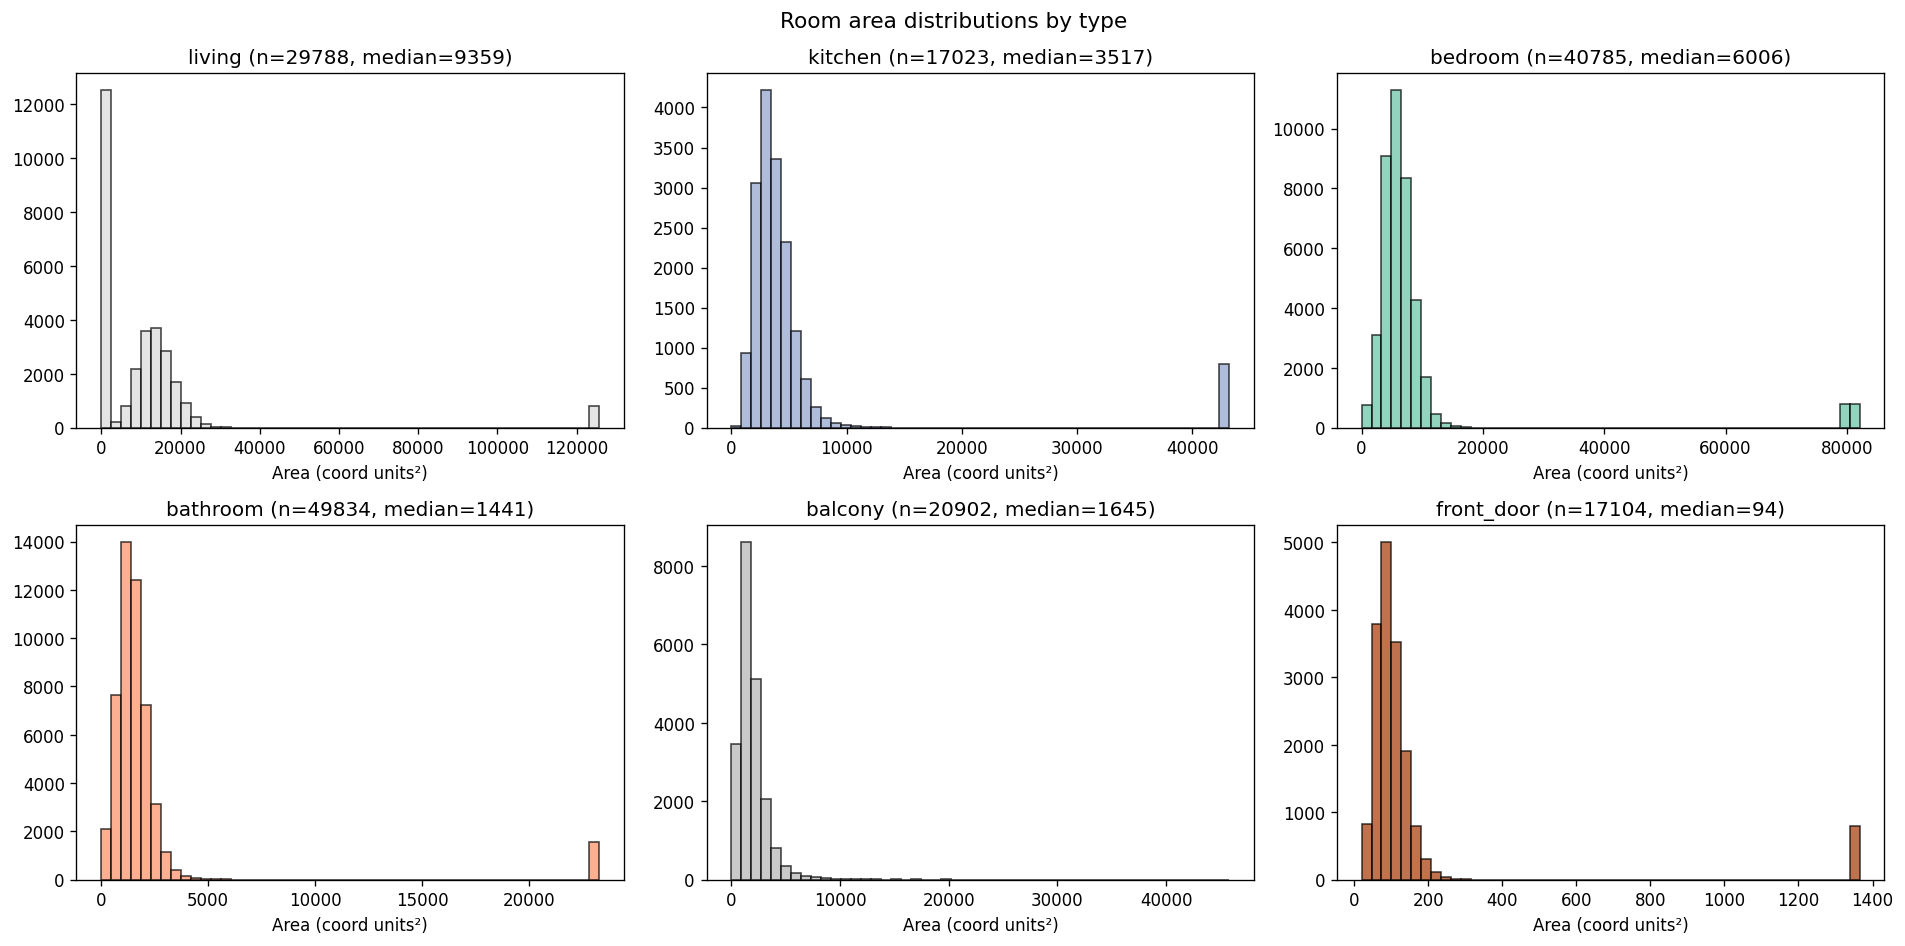

In [25]:
# Collect room areas by type
room_areas_by_type = defaultdict(list)

for p in plans:
    for key in ROOM_KEYS:
        for geom in get_geometries(p.get(key)):
            if isinstance(geom, Polygon) and not geom.is_empty:
                room_areas_by_type[key].append(geom.area)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, key in zip(axes.flat, ROOM_KEYS):
    areas = room_areas_by_type.get(key, [])
    if areas:
        areas = np.array(areas)
        ax.hist(areas, bins=50, edgecolor="black", alpha=0.7,
                color=CATEGORY_COLORS.get(key, "#999"))
        ax.set_title(f"{key} (n={len(areas)}, median={np.median(areas):.0f})")
        ax.set_xlabel("Area (coord units²)")
    else:
        ax.set_title(f"{key} — no data")
        ax.axis("off")

plt.suptitle("Room area distributions by type", fontsize=13)
plt.tight_layout()
plt.show()

## 12. Metadata fields

Plans also contain non-geometry metadata like `unitType`, `id`, `area`, `net_area`.
Let's see what's there.

unitType distribution:
  'Apartment'                     15854  (92.7%)
  'BuilderFloor'                    821  (4.8%)
  'Villa'                           384  (2.2%)
  'IndependentHouse'                 48  (0.3%)


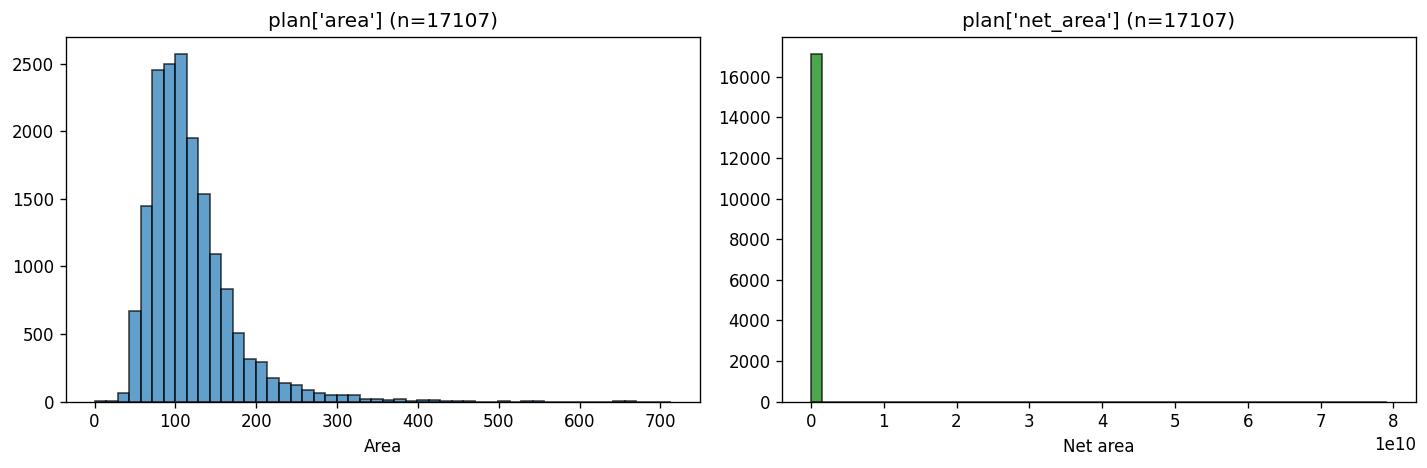


Sample plan IDs: [13, 0, 12, 14, 20]


In [26]:
# Inspect non-geometry metadata fields
META_KEYS = ["unitType", "id", "area", "net_area", "wall_width", "living"]

# unitType distribution
unit_types = Counter(p.get("unitType") for p in plans if p.get("unitType") is not None)
print("unitType distribution:")
for ut, count in unit_types.most_common(20):
    print(f"  {ut!r:30s}  {count:5d}  ({100*count/len(plans):.1f}%)")

# area and net_area
areas = [p.get("area") for p in plans if p.get("area") is not None]
net_areas = [p.get("net_area") for p in plans if p.get("net_area") is not None]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if areas:
    axes[0].hist(areas, bins=50, edgecolor="black", alpha=0.7)
    axes[0].set_title(f"plan['area'] (n={len(areas)})")
    axes[0].set_xlabel("Area")
if net_areas:
    axes[1].hist(net_areas, bins=50, edgecolor="black", alpha=0.7, color="green")
    axes[1].set_title(f"plan['net_area'] (n={len(net_areas)})")
    axes[1].set_xlabel("Net area")
plt.tight_layout()
plt.show()

# Show a few sample IDs
sample_ids = [p.get("id") for p in plans[:5]]
print(f"\nSample plan IDs: {sample_ids}")